# 10.2. 침투와 오비탈 에너지

In [1]:
import numpy as np
from scipy.special import genlaguerre, factorial
from scipy.constants import physical_constants as pc

a0 = pc["Bohr radius"][0]


def R(n, l, r, Z=1):
    """수소꼴 원자의 지름 함수"""
    rho = 2 * Z * r / (n * a0)
    norm = np.sqrt((2 * Z / (n * a0))**3 * factorial(n - l - 1) / (2 * n * factorial(n + l)))
    return norm * np.exp(-rho / 2) * rho**l * genlaguerre(n - l - 1, 2 * l + 1)(rho)


def P(n, l, r, Z=1):
    """지름 분포 함수"""
    return R(n, l, r, Z) ** 2 * r**2


# 규격화 확인
r = np.linspace(1e-8 * a0, 80 * a0, 100000)
for n, l in [(2, 0), (2, 1), (3, 0), (3, 2), (4, 0)]:
    print(f"({n}, {l}): {np.trapezoid(P(n, l, r), r):.6f}")

(2, 0): 1.000000
(2, 1): 1.000000
(3, 0): 1.000000
(3, 2): 1.000000
(4, 0): 1.000000


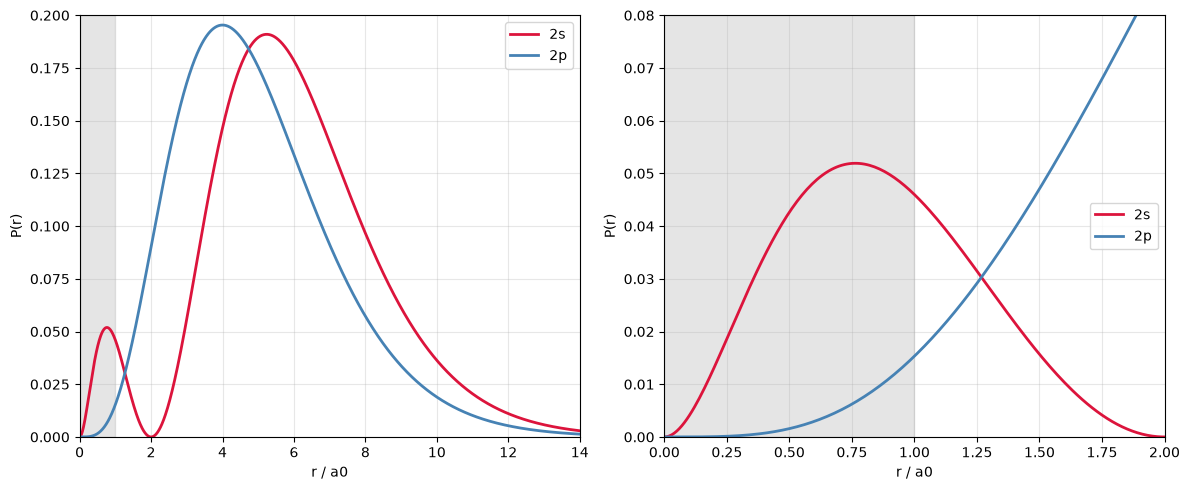

In [2]:
import matplotlib.pyplot as plt

r = np.linspace(1e-6 * a0, 20 * a0, 2000)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 5))

for n, l, name, col in [(2, 0, "2s", "crimson"), (2, 1, "2p", "steelblue")]:
    a1.plot(r / a0, P(n, l, r) * a0, lw=2, color=col, label=name)
    a2.plot(r / a0, P(n, l, r) * a0, lw=2, color=col, label=name)

a1.axvspan(0, 1, color="gray", alpha=0.2)
a1.set_xlim(0, 14)
a1.set_ylim(0, 0.2)
a1.set_xlabel("r / a0")
a1.set_ylabel("P(r)")
a1.legend(fontsize=10)
a1.grid(alpha=0.3)

a2.axvspan(0, 1, color="gray", alpha=0.2)
a2.set_xlim(0, 2)
a2.set_ylim(0, 0.08)
a2.set_xlabel("r / a0")
a2.set_ylabel("P(r)")
a2.legend(fontsize=10)
a2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [3]:
r = np.linspace(1e-6 * a0, 20 * a0, 2000)
core = r < (1.0 * a0)

for n, l, name in [(2, 0, "2s"), (2, 1, "2p")]:
    inner = np.trapezoid(P(n, l, r)[core], r[core])
    r_mean = np.trapezoid(P(n, l, r) * r, r) / a0
    print(f"{name}: <r> = {r_mean:.2f} a0, r < a0일 확률: {inner * 100:.2f} %")

2s: <r> = 6.00 a0, r < a0일 확률: 3.39 %
2p: <r> = 5.00 a0, r < a0일 확률: 0.35 %


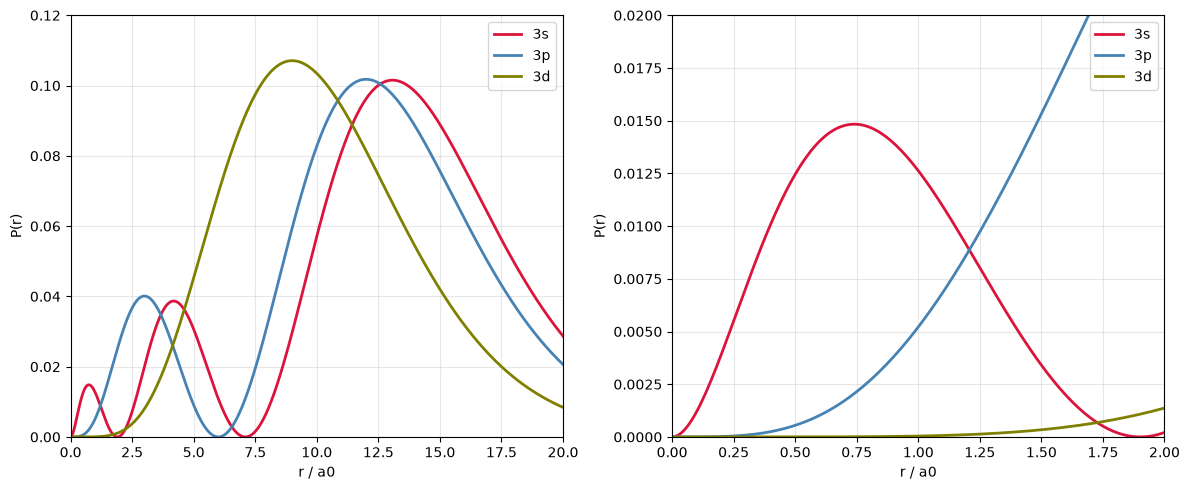

In [4]:
r = np.linspace(1e-6 * a0, 20 * a0, 2000)

fig, (b1, b2) = plt.subplots(1, 2, figsize=(12, 5))

for n, l, name, col in [(3, 0, "3s", "crimson"), (3, 1, "3p", "steelblue"), (3, 2, "3d", "olive")]:
    b1.plot(r / a0, P(n, l, r) * a0, lw=2, color=col, label=name)
    b2.plot(r / a0, P(n, l, r) * a0, lw=2, color=col, label=name)

b1.set_xlim(0, 20)
b1.set_ylim(0, 0.12)
b1.set_xlabel("r / a0")
b1.set_ylabel("P(r)")
b1.legend(fontsize=10)
b1.grid(alpha=0.3)

b2.set_xlim(0, 2)
b2.set_ylim(0, 0.02)
b2.set_xlabel("r / a0")
b2.set_ylabel("P(r)")
b2.legend(fontsize=10)
b2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
r = np.linspace(1e-6 * a0, 100 * a0, 2000)
core = r < (1.0 * a0)

for n, l, name in [(3, 0, "3s"), (3, 1, "3p"), (3, 2, "3d")]:
    inner = np.trapezoid(P(n, l, r)[core], r[core])
    r_mean = np.trapezoid(P(n, l, r) * r, r) / a0
    print(f"{name}: <r> = {r_mean:.2f} a0, r < a0일 확률: {inner * 100:.4f} %")

3s: <r> = 13.50 a0, r < a0일 확률: 0.9220 %
3p: <r> = 12.50 a0, r < a0일 확률: 0.1021 %
3d: <r> = 10.50 a0, r < a0일 확률: 0.0005 %


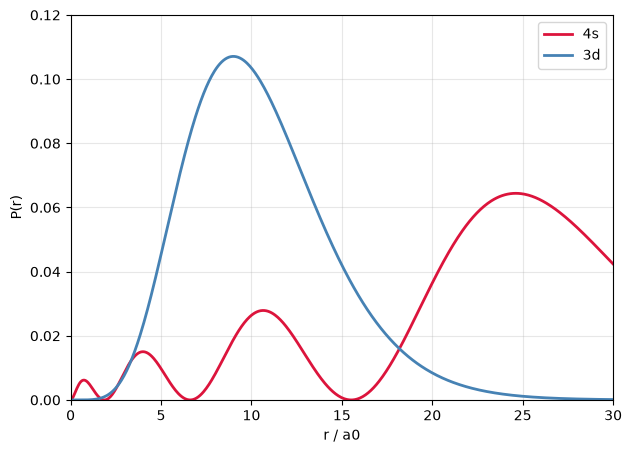

4s: <r> = 24.00 a0, r < a0일 확률: 0.3853 %
3d: <r> = 10.50 a0, r < a0일 확률: 0.0005 %


In [6]:
r = np.linspace(1e-6 * a0, 100 * a0, 2000)

fig, ax = plt.subplots(figsize=(7, 5))

for n, l, name, col in [(4, 0, "4s", "crimson"), (3, 2, "3d", "steelblue")]:
    ax.plot(r / a0, P(n, l, r) * a0, lw=2, color=col, label=name)

ax.set_xlim(0, 30)
ax.set_ylim(0, 0.12)
ax.set_xlabel("r / a0")
ax.set_ylabel("P(r)")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.show()

core = r < (1.0 * a0)

for n, l, name in [(4, 0, "4s"), (3, 2, "3d")]:
    inner = np.trapezoid(P(n, l, r)[core], r[core])
    r_mean = np.trapezoid(P(n, l, r) * r, r) / a0
    print(f"{name}: <r> = {r_mean:.2f} a0, r < a0일 확률: {inner * 100:.4f} %")